# Radial velocity analysis of WASP-12b 

**Universidad de La Laguna Exo & Exo 2025-2026 exercise 1**

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

This first exercise teaches you how to estimate the minimum planetary mass from radial velocity measurements using [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference).

**Exercise style:** 
- Use astropy constants, units, and unit conversions where possible.
- Carry out the calculations using posterior sample arrays instead of point estimates whenever possible. This ensures correct uncertainty propagation.


## 1.1 (The absolute basics of) radial velocities

A planet orbiting a star causes the star to [move around the star-planet barycentre](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/#/1). This leads to a periodic change in the star's position and velocity,
and the radial component of the star's velocity can be measured using [doppler spectroscopy](https://en.wikipedia.org/wiki/Doppler_spectroscopy). Radial velocity (RV) measurements are used to search for unknown planets and to estimate the minimum masses and orbital periods of known planets.

![Doppler shift vs time](Doppler_Shift_vs_Time.svg "Doppler shift vs time")


A planet with a mass $M_\mathrm{p}$ orbiting a star with a mass $M_\star$ with an orbital period $P$ leads to a periodic signal with a semi-amplitude of

$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

where $G$ is the [gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant), $e$ is the [orbital eccentricity](https://en.wikipedia.org/wiki/Orbital_eccentricity), and $i$ is the [orbital inclination](https://en.wikipedia.org/wiki/Orbital_inclination). After we estimate $P$, $K$, and $M_\star$ we can solve for the minimum planetary mass $M_\mathrm{p} \sin i$. The orbital period and RV semi-amplitude can be estimated directly from the RV signal, but the stellar mass needs to be estimated using other means.


## 1.2 (The absolute basics of) Bayesian parameter estimation

Measuring the RV semi-amplitude and the orbital period from RV measurements is a *parameter estimation* problem: we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties.

We take a [*Bayesian*](http://en.wikipedia.org/wiki/Bayesian_probability) approach to the parameter estimation, where we want to estimate the [*posterior probability*](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [*prior probabilities*](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by the [*Bayes' theorem*](http://en.wikipedia.org/wiki/Bayes%27_theorem) as

$$
P(\theta|D) = \frac{P(\theta) P(D|\theta)}{P(D)}, \qquad P(D|\theta) = \prod P(D_i|\theta),
$$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [*likelihood*](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [*normalising factor*](http://en.wikipedia.org/wiki/Marginal_likelihood) we don't need to bother with during MCMC-based parameter estimation. 

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead, so that

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

where we have omitted the $P(D)$ term from the posterior density.

Now we still need to decide our likelihood density. If we can assume normally distributed white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. 

This should be enough for these exercies, but you can find more information from [A primer about Bayesian statistics](https://ui.adsabs.harvard.edu/link_gateway/2018haex.bookE.149P/EPRINT_PDF) and the references therein.

## 2.1 Initialisation

In [1]:
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, median
from astropy.table import Table
from astropy.timeseries import LombScargle
from corner import corner

from pytransit.lpf.rvlpf import RVLPF

rc('figure', figsize=(13,4))

## 2.1 Read in the RV data 

The radial velocity measurements consist of mid-observation times, radial velocity values, and radial velocity measurement uncertainties (also called as 'errors'). We use the data from [Yee et al. (2019)](https://iopscience.iop.org/article/10.3847/2041-8213/ab5c16). The data is stored as a CDS table that can be read directly using `astropy.table.Table`.

In [2]:
rv_data = Table.read('data/wasp_12b_yee_2019.dat', format='ascii.cds')

It's important to understand what sort of data we're dealing with, so we begin by displaying the table header and the five first rows.

In [3]:
rv_data[:5]  

BJD,RVel,e_RVel
d,m / s,m / s
float64,float64,float64
2455521.959432,-136.635,2.534
2455543.089922,5.728,2.919
2455545.983884,-162.39,2.822
2455559.906718,141.616,2.345
2455559.917563,115.818,2.727


It's also useful to visualise directly what we're working with, so we next plot the radial velocity data and its uncertainties as a function of time.

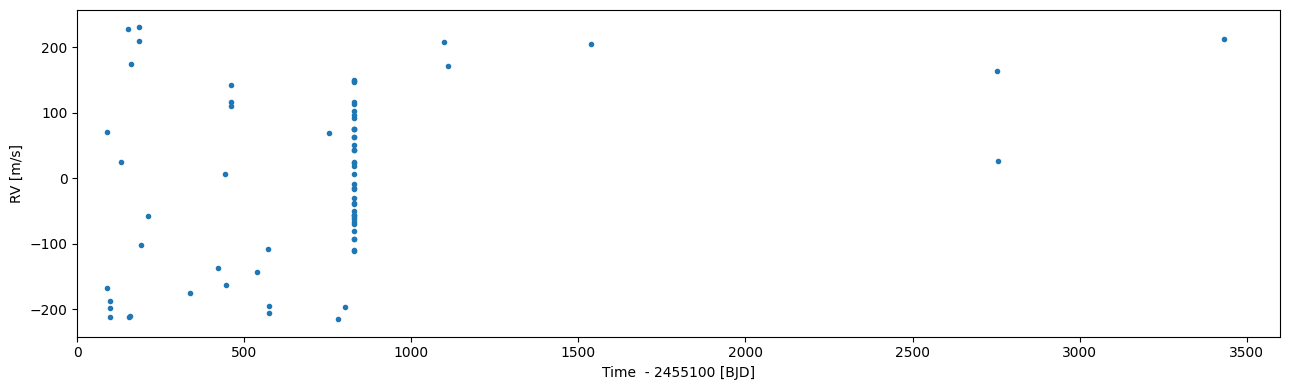

In [4]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(0, 3600))
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe the logic behind the time sampling of the RV observations.

- The radial velocity (RV) observations time sampling is not consistent or evenly spaced. Rather, it is purposefully made to capture the periodic nature of the planet-induced signal.

    Because the goal is to measure a periodic Doppler shift caused by the orbit of WASP-12b, observations are typically taken at different phases of the orbit rather than at regular time intervals.  This implies that when the radial velocity is predicted to change quickly (close to the RV curve's extrema), several measurements are grouped together, whereas fewer observations might be made       when the signal varies slowly.

    In reality, the availability of telescopes, weather, and the target star's visibility from Earth all have an impact on the sampling. The dataset frequently displays erratic gaps and clusters in      time as a result. By covering different regions of the RV curve, this uneven sampling actually helps to better constrain the orbital period and the semi-amplitude, thereby reducing degeneracies      that could result from strictly uniform sampling.

2. Plot below the RV observations as a function of time focusing on the densely-sampled time-span.

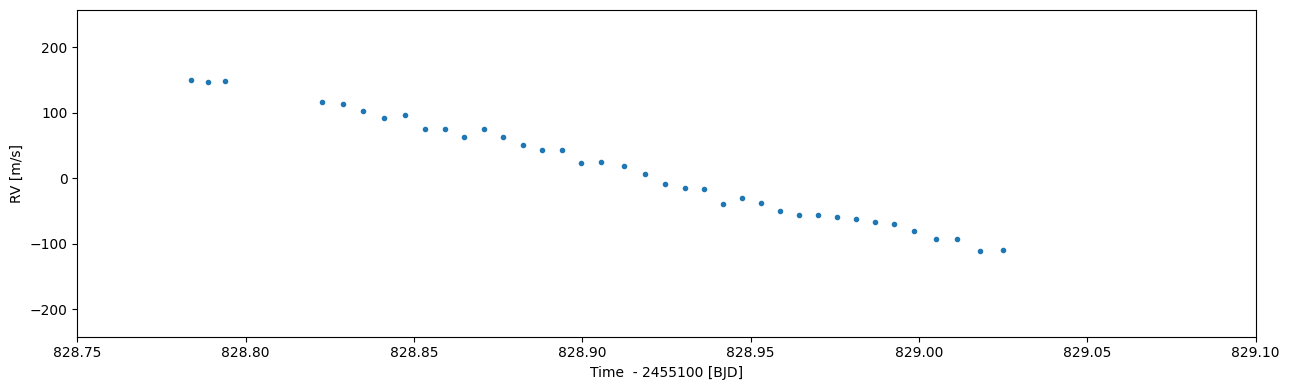

In [5]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(828.75, 829.1))
fig.tight_layout()

## 2.2 Search for a radial velocity signal

First, we use a Lomb-Scargle periodigram to search for a sinusoidial radial velocity signal from the RV measurements. This is simple to do with `astropy.timeseries.LombScargle` class that is initialised with the mid-measurement times and the RV observations.

In [6]:
ls = LombScargle(rv_data['BJD'], rv_data['RVel'])

Next, we use the `LombScargle.autopower` to calculate the periodogram. We restrict the search to $0.5 < P < 5$ days.

In [7]:
frequency, power = ls.autopower(minimum_frequency=1/(5*u.d), maximum_frequency=2/u.d)
period = 1/frequency

In [8]:
best_period = period[argmax(power)]
best_period

<Quantity 1.09144998 d>

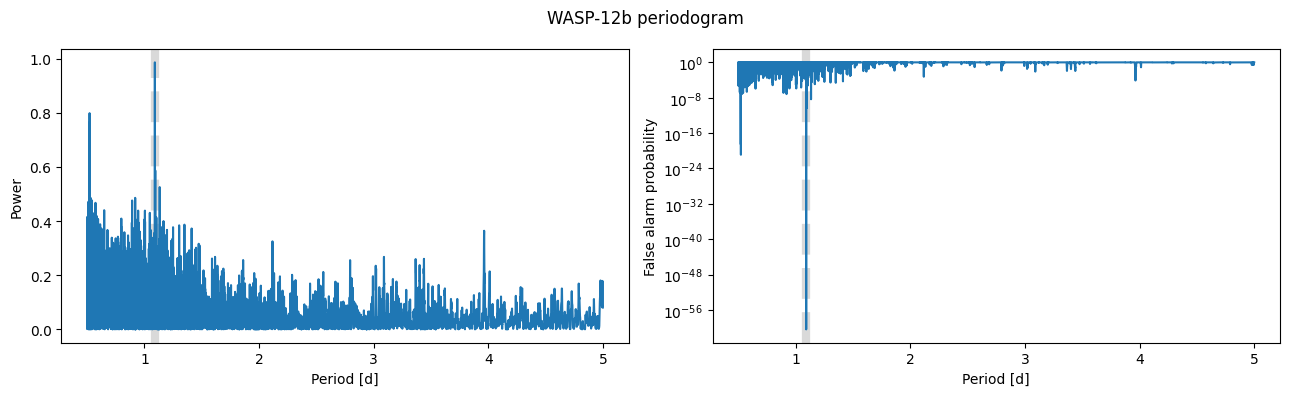

In [9]:
fig, axs = subplots(1, 2, figsize=(13,4))
axs[0].plot(period, power)
axs[1].semilogy(period, ls.false_alarm_probability(power))
[ax.axvline(best_period.value, c='k', ls='--', zorder=-1, lw=6, alpha=0.15) for ax in axs]
setp(axs, xlabel='Period [d]')
setp(axs[0], ylabel='Power')
setp(axs[1], ylabel='False alarm probability')
fig.suptitle('WASP-12b periodogram')
fig.tight_layout()

Let's see what happens when we plot the RV values folded over the best period.

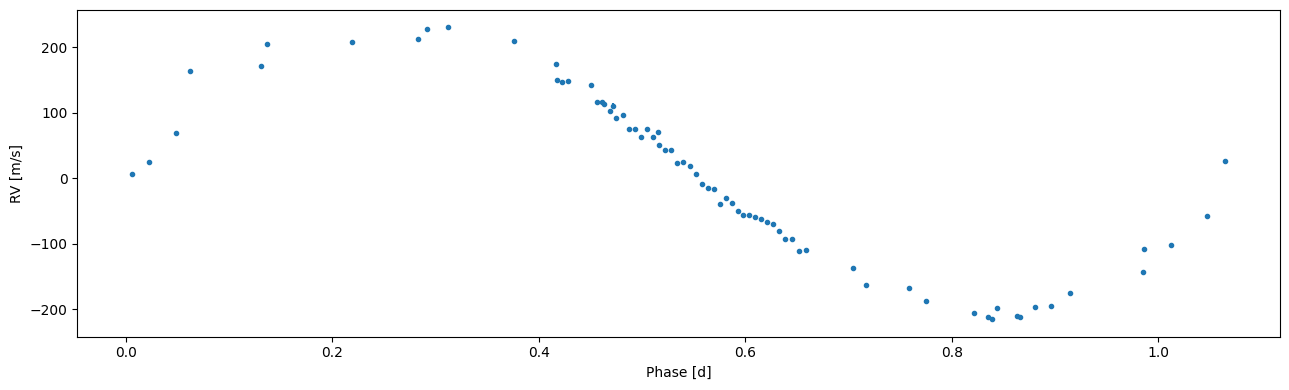

In [10]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] % best_period.value, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Phase [d]', ylabel='RV [m/s]')
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe what the Lomb-Scargle power and false alarm probability mean.

- The degree to which a sinusoidal signal at a particular frequency matches the observed data is measured by the Lomb-Scargle power. The algorithm determines how well a sine wave fits the data for each of the numerous trial frequencies tested in a Lomb–Scargle periodogram. The resulting power indicates how much of the variance in the data can be accounted for by a periodic signal at that frequency. A low power implies that there isn't a significant signal at that frequency in the data, whereas a high power suggests a strong candidate periodicity.

    The false alarm probability (FAP) is a statistical measure associated with each tested frequency that quantifies the probability that a peak of that power could arise purely from random noise in the absence of a real periodic signal. When computed over all frequencies, the FAP provides a significance estimate for each candidate periodicity in the periodogram. Low FAP values indicate that the corresponding peak is unlikely to be produced by noise and thus represent statistically significant periodic signals, whereas high values suggest that the observed power could plausibly result from random fluctuations.

    As can be seen, the peak in the Lomb–Scargle power at a period of 1.09415 days is associated with a very low FAP. This indicates that the likelihood of such a strong peak arising from random noise is extremely small. These suggest that the data shows a statistically significant periodic behaviour at this period.


## 2.3 Radial velocity modelling

Now when we know the RV data contains a suspicious signal, we can model it to study what sort of an object is causing it. The two most important parameters we're interested are the orbital period and radial velocity semiamplitude (K). The RV semiamplitude will give us the lower limit of the object's mass ($m\sin i$) which will then tell us whether we're dealing with a planet or something else.

### Initialise the model

In [11]:
lpf = RVLPF('WASP-12b', 1, rv_data['BJD'], rv_data['RVel'], rv_data['e_RVel'])

In [12]:
lpf.ps

[  0 |G| tc_1           N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 1.0)                      [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 1.0)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     N(μ = 0.0, σ = 1.0)                      [    -inf ..      inf]]

The parameters are

- `tc_1`: transit center [BJD]
- `p_1`: orbital period [d]
- `secw_1`: $\sqrt{e} \cos\omega$, where $e$ is the eccentricity and $\omega$ the argument of periastron
- `sesw_1`: $\sqrt{e} \sin\omega$
- `rv_shift_0`: systemic velocity [m/s]
- `rv_err_0`: additional white noise [m/s]
- `rv_k_1` RV semiamplitude [m/s]
- `rv_slope`: additional linear slope

### Set the parameter priors

Bayesian inference requires a prior probability distribution for each of our model parameters. These "priors" can be based on previous studies, theoretical expectations, or more generally in our beliefs on what values the parameters can take.

In this case we use two priors: a normal prior (NP) and a uniform prior (UP). The normal prior models our prior belief using a normal distribution with a known mean and standard deviation, while the uniform prior says that the paramer can take any value between a minimum and maximum boundary.

In [13]:
lpf.set_prior('tc_1', 'NP', 2458480.65, 0.02) # Normal prior (mean, sigma)
lpf.set_prior('p_1', 'NP', 1.09, 0.1)
lpf.set_prior('rv_shift_0', 'NP', 0.0, 10)
lpf.set_prior('rv_err_0', 'UP', 0.0, 30.0) # Uniform prior (min, max)
lpf.set_prior('rv_k_1', 'UP', 0.0, 300)
lpf.set_prior('rv_slope_1', 'UP', 0.0, 1e-5)

In [14]:
lpf.ps

[  0 |G| tc_1           N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.09, σ = 0.1)                     [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 10.0)                     [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 30.0)                     [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 300)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     U(a = 0.0, b = 1e-05)                    [    -inf ..      inf]]

### Fit the model to the data

Global optimisation:   0%|          | 0/2000 [00:00<?, ?it/s]

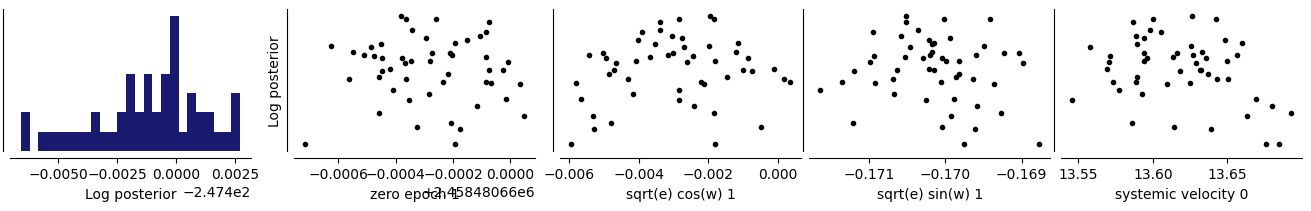

In [15]:
lpf.optimize_global(2000)

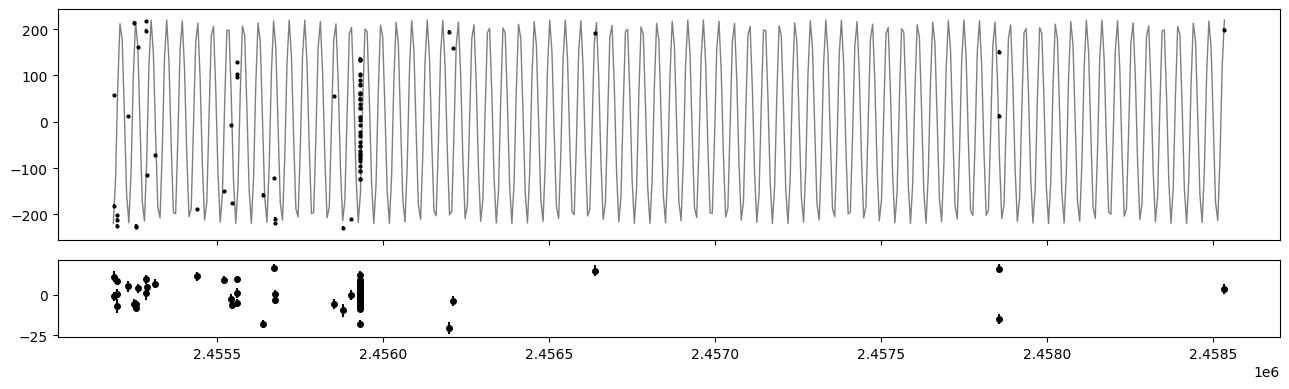

In [16]:
lpf.plot_rv_vs_time();

C:\Users\david\OneDrive\Master\Primero\Segundo cuatrimestre\Exoplanetas y exobiología\Práctica\practica_exo\Lib\site-packages\pytransit\lpf\rvlpf.py:370: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  axs[0].errorbar(phase[m], rvs[m], self._rvea[m], fmt='o', marker=markers[iid],


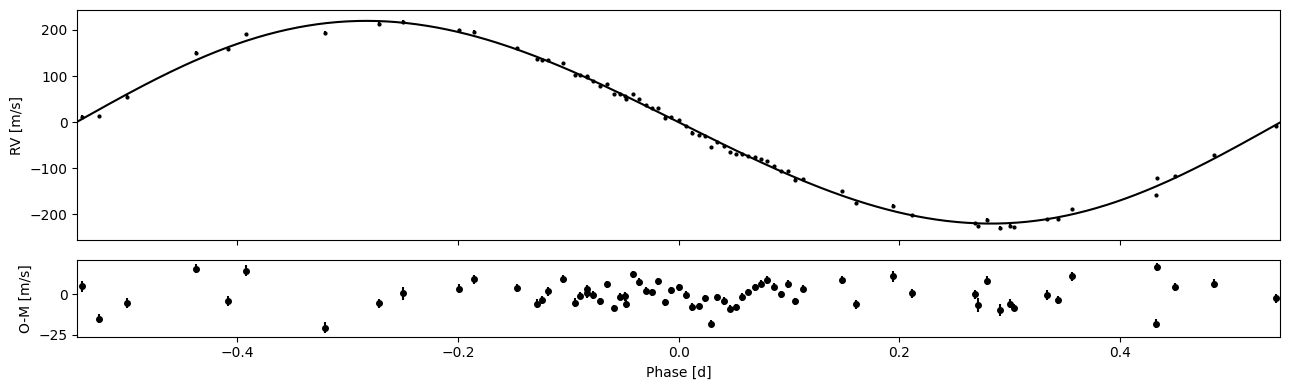

In [17]:
lpf.plot_rv_vs_phase(0);

### Estimate the parameter posterior distributions using MCMC

We estimate the [posterior probability distributions](https://en.wikipedia.org/wiki/Posterior_probability) of our model parameters using [Markov Chain Monte Carlo sampling](https://twiecki.io/blog/2015/11/10/mcmc-sampling). The sampling can be done using the `RVLPF.sample_mcmc` method after a global optimisation run has been finished. The `sample_mcmc` method uses the [*emcee*](https://emcee.readthedocs.io/en/stable) sampler under the hood.

We give `RVLPF.sample_mcmc` the number of MCMC steps to take (`niter`), a thinning factor (`thin`), and a number of repeats (`repeats`). This makes the sampler run first one round of `niter` steps, restarts the sampler from the last step of the previous run, and run again `niter` steps. This is the same as running the sampler for `2 x niter` and keeping only the second half of the steps. The first half is treated as a [warm-up period](https://stats.stackexchange.com/questions/88819/mcmc-methods-burning-samples) for the sampler and discarded. In general, the sampler is run `repeats x niter` steps in total, and only the last `niter` steps are retained.

The thinning factor tells the sampler to store only every $n$th step. In our case, we're storing only every 10th step. Thinning is a way to try to store only statistically independent samples, but is [not really necessary](https://besjournals.onlinelibrary.wiley.com/doi/pdf/10.1111/j.2041-210X.2011.00131.x). However, we'll do it to keep the number of samples low (there's no point in storing a large number of dependent samples either).

In [18]:
lpf.sample_mcmc(niter=2000, thin=10, repeats=2)

MCMC sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1/2:   0%|          | 0/2000 [00:00<?, ?it/s]

Run 2/2:   0%|          | 0/2000 [00:00<?, ?it/s]

The *emcee* sampler uses an ensemble of MCMC chains to sample the posterior. This means that we have many chains running in parallel. We can plot the traces of each chain to see how the chain population behaves in time.

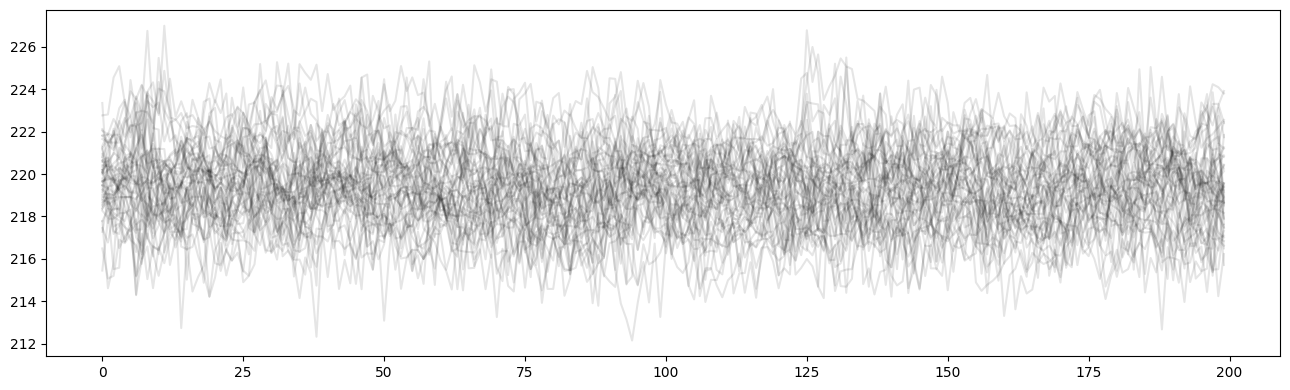

In [19]:
lpf.plot_mcmc_chains(6);

### Plot the model posterior

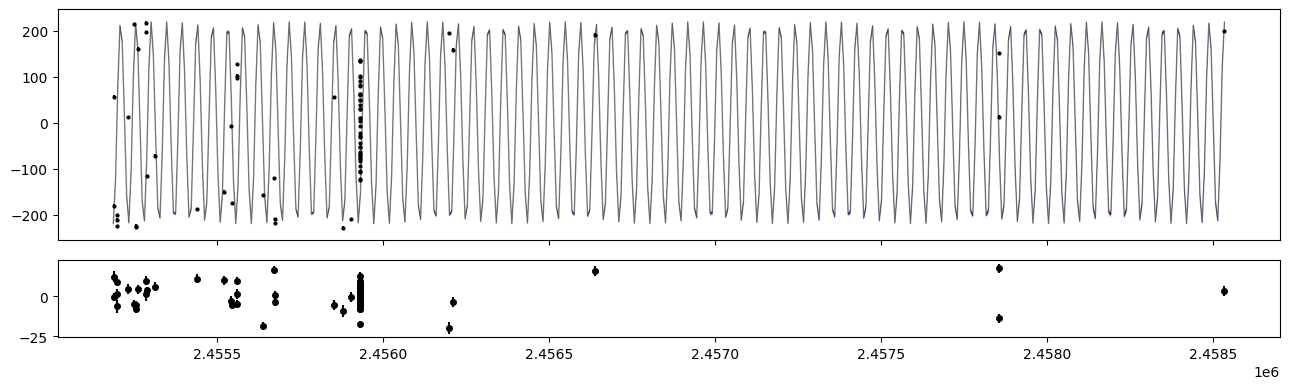

In [20]:
lpf.plot_rv_vs_time('mcmc');

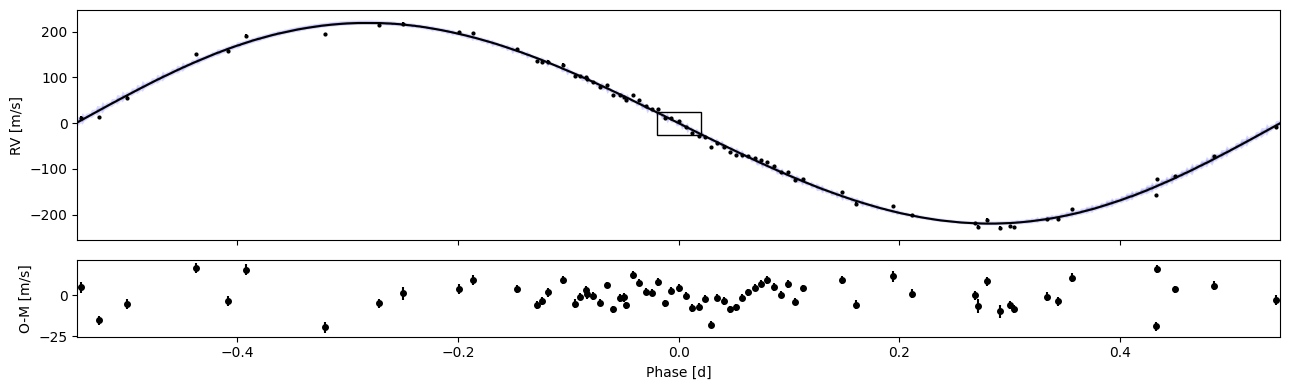

In [21]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
fig.axes[0].add_patch(Rectangle((-.02, -25), 0.04, 50, fill=False));

When we zoom a little bit, we can see that we're now actually plotting the probability density of the model. The black line corresponds to the median of the model posterior, and the two shades to the 68% and 95% central posterior limits.

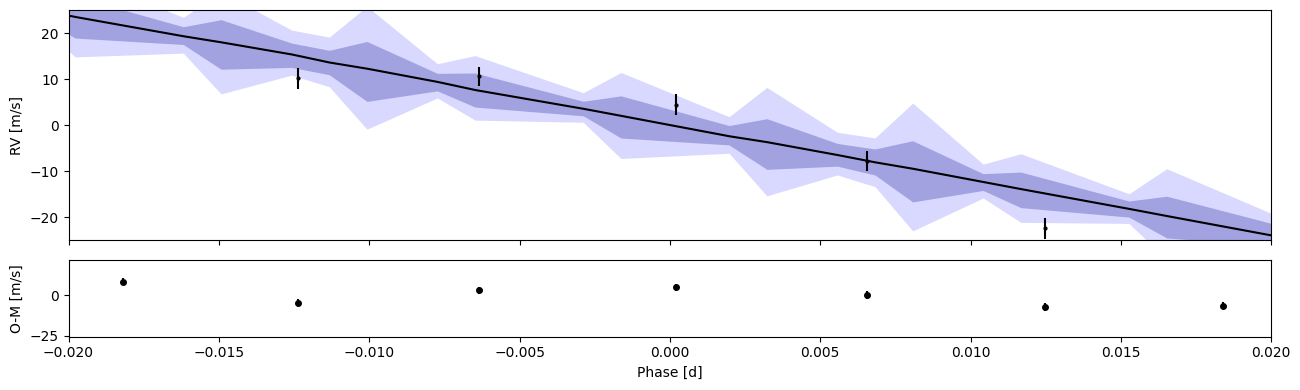

In [22]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
setp(fig.axes[0], xlim=(-0.02, 0.02), ylim=(-25,25));

### Plot the parameter posteriors

In [23]:
df = lpf.posterior_samples()
df

,tc_1,p_1,secw_1,sesw_1,rv_shift_0,rv_err_0,rv_k_1,rv_slope_1
0,2.458481e+06,1.091422,0.044358,-0.167878,13.119493,7.351475,219.674959,2.078880e-06
1,2.458481e+06,1.091422,0.055284,-0.160564,12.341021,7.712438,219.732668,1.389248e-06
2,2.458481e+06,1.091423,0.039886,-0.157880,12.742690,7.669210,219.818926,2.292600e-06
3,2.458481e+06,1.091423,0.013792,-0.164392,12.144575,8.409775,218.905184,9.199481e-07
4,2.458481e+06,1.091423,0.015443,-0.165262,12.090402,8.417935,218.918166,8.505918e-07
...,...,...,...,...,...,...,...,...
9995,2.458481e+06,1.091424,0.015576,-0.184253,11.009716,6.723110,220.347942,8.163325e-06
9996,2.458481e+06,1.091424,0.049221,-0.185088,11.874499,7.348542,221.215140,6.870148e-06
9997,2.458481e+06,1.091424,0.029407,-0.171133,12.667002,7.683383,221.577001,5.628596e-06
9998,2.458481e+06,1.091423,0.006198,-0.176054,12.314674,7.975413,221.761186,3.391997e-06


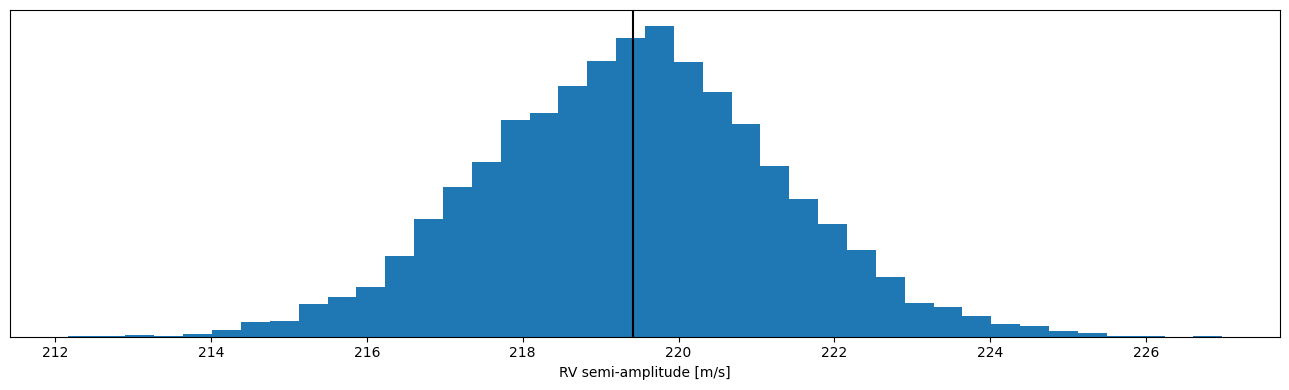

In [24]:
fig, ax = subplots()
ax.hist(df.rv_k_1, bins=40)
ax.axvline(median(df.rv_k_1), c='k')
setp(ax, xlabel='RV semi-amplitude [m/s]', yticks=[])
fig.tight_layout()

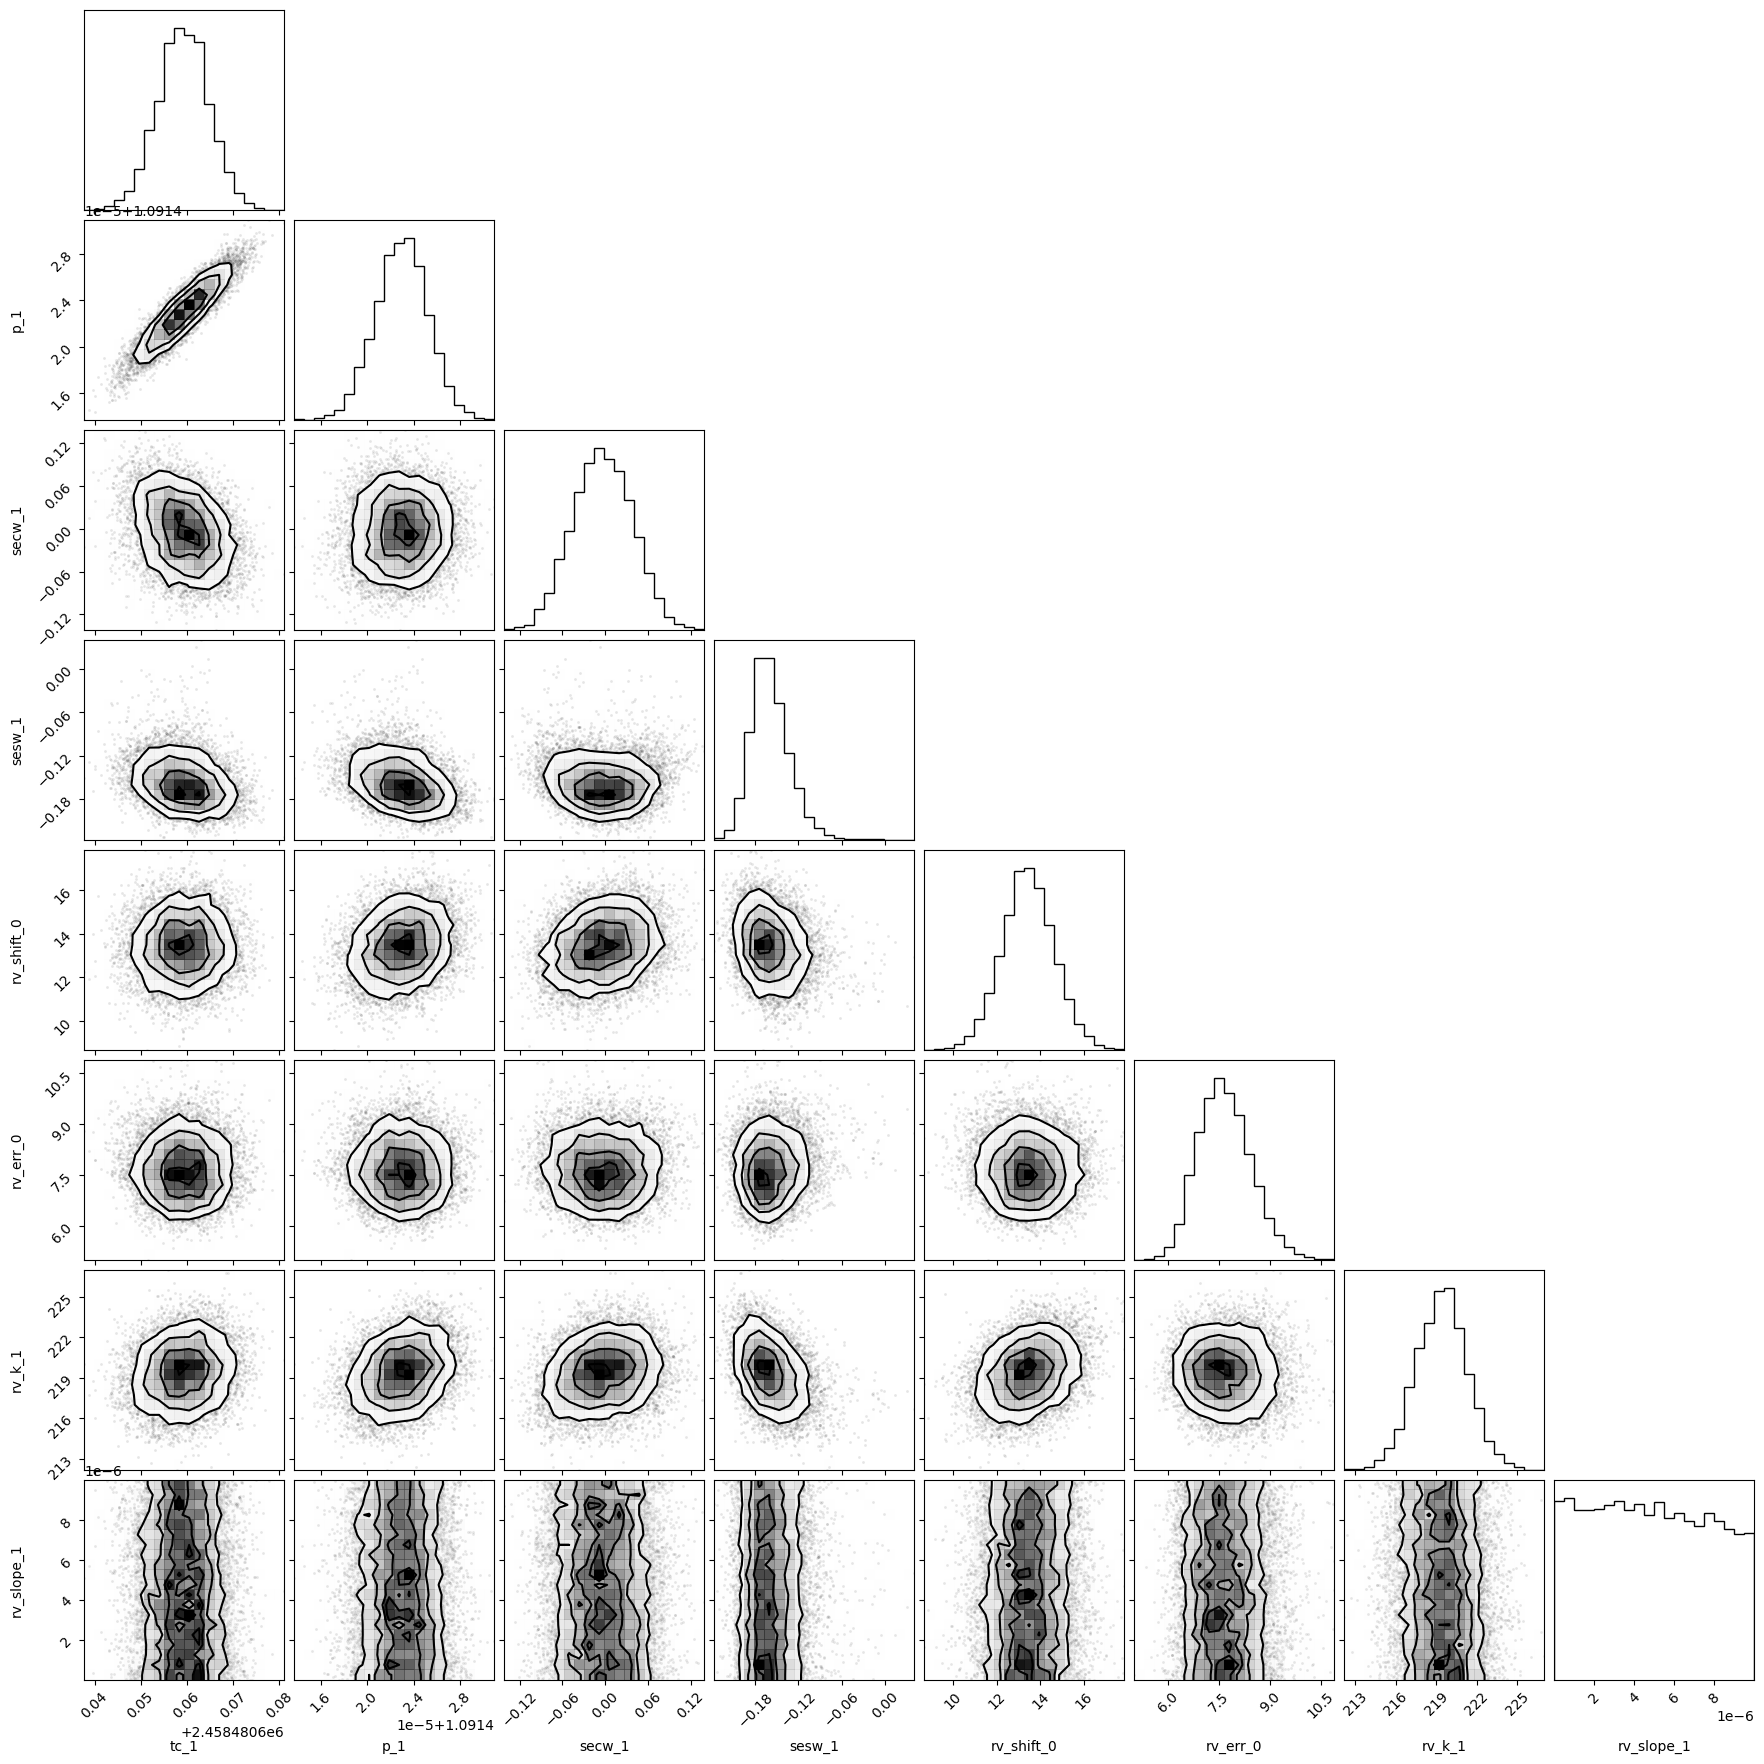

In [25]:
corner(df.values, labels=df.columns);

### <span style="color:darkblue">Questions and exercises</span>

1. What is the posterior density for the minimum mass ($m\sin i$) of WASP-12b? You can derive this from the RV semi-amplitude (K), orbital period (p), and the host star mass.

Derive the equation for the minimum mass, do the calculations using posterior samples, report both the mass median and its 68th percentile uncertainties, and plot the distribution. Use astropy constants, units, and unit conversions where needed.

- From the expression shown at the beginning of the notebook, assuming the mass of WASP-12b is very small in comparison with the star's mass ($M_p$ << $M_*$) and the eccentricity $e\approx0$, the minimum mass of WASP-12b follows the next expression:
$$
m \sin i = \left( \frac{P}{2\pi G} \right)^{1/3} M_*^{2/3} K
$$
The posterior density for the minimum mass can be obtained with this expression using the posterior samples. The mass of WASP-12 was obtained from https://www.stellarcatalog.com/estrellas/wasp-12

m sin i = 1.411 (+0.012/-0.012) Mjup


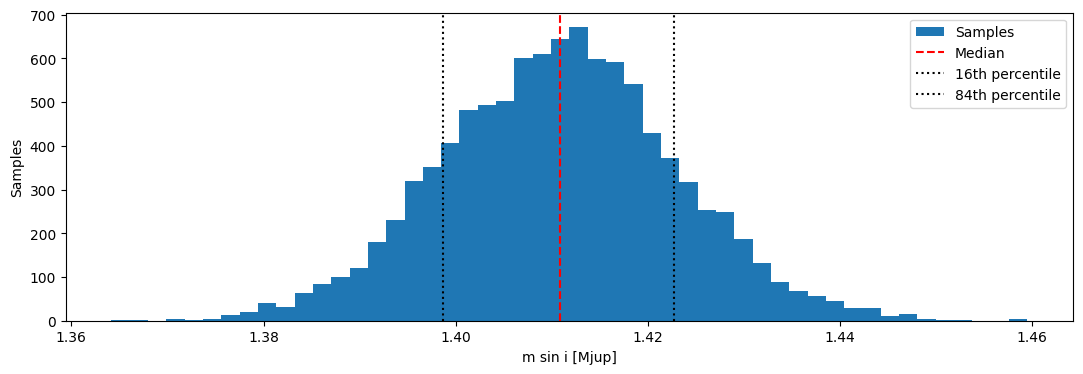

In [26]:
import numpy as np
import astropy.units as u
from astropy.constants import G

K = df["rv_k_1"].values * u.m/u.s # RV-semi-amplitude
P = df["p_1"].values * u.day # Orbital period
P = P.to(u.s) 


Mstar = 1.43 * u.M_sun # Star's mass

m_sini = K * (Mstar**(2/3)) * ((P/(2*np.pi*G))**(1/3))

m_sini = m_sini.to(u.M_jup) # M sin(i) posterior density

median = np.median(m_sini.value) # Median mass
p16 = np.percentile(m_sini.value, 16) # 16th percentile
p84 = np.percentile(m_sini.value, 84) # 84th percentile

np.save("m_sini_samples.npy", m_sini.value) # Saving the mass density for later

print(f"m sin i = {median:.3f} (+{p84-median:.3f}/-{median-p16:.3f}) Mjup")

plt.hist(m_sini.value, bins=50, label="Samples")

plt.axvline(median, linestyle="--", color='red', label="Median")
plt.axvline(p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel("m sin i [Mjup]")
plt.ylabel("Samples")

plt.legend()
plt.show()

2. What can you tell about WASP-12b as a planet based on its minimum mass and orbital period?

- WASP-12b can be classified as a typical hot Jupiter, given its minimum mass of about $1.41\,M_{\mathrm{Jup}}$ and its short orbital period of approximately 1.09 days, which implies that it orbits extremely close to its host star. Such proximity leads to very high atmospheric temperatures, significant atmospheric inflation, and consequently a low bulk density, while tidal interactions are expected to have synchronized the planet’s rotation with its orbit, causing it to be tidally locked. Planets of this type are thought to migrate inward from larger orbital distances, and due to its closeness to the star, WASP-12b may also be experiencing atmospheric escape and possible tidal deformation.



3. We parameterise the model using ($\sqrt{e}\sin\omega$, $\sqrt{e}\cos\omega$) instead of ($e$, $\omega$). This parameterisation is more efficient to sample with an MCMC sampler, but means we need to take some extra steps to get the eccentricity and argument of periastron samples. Write below the equations you need to use to map the sampling parameters to $e$ and $\omega$?

- The equations needed to compute $e$ and $\omega$, given that $secw_1=\sqrt{e} \, cos(\omega$) and $secw_1=\sqrt{e} \, sen(\omega$):

$$
\mathrm{e=secw_1^2+sesw_1^2}
$$

$$
\mathrm{\omega=tg \left( \frac{sesw_1}{secw_1} \right)}
$$

4. Derive $e$ and $\omega$ from the MCMC samples and plot their histograms.

In [27]:
secw = df["secw_1"].values # Secw_1
sesw = df["sesw_1"].values # Sesw_1

e = secw**2 + sesw**2 # Orbital eccentricity

w = np.arctan2(sesw, secw) 

w_deg = np.degrees(w)

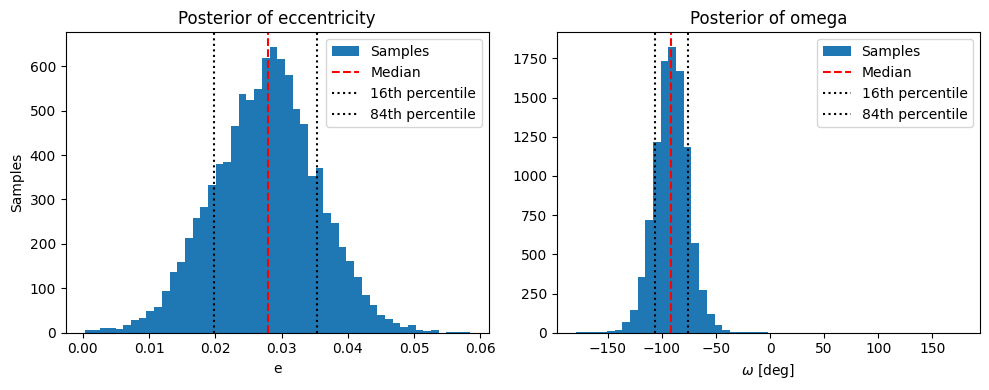

In [28]:
e_median = np.percentile(e, 50) # Median orbital eccentricity
e_p16 = np.percentile(e, 16) # 16th percentile
e_p84 = np.percentile(e, 84) # 84th percentile


w_median = np.percentile(w_deg, 50) # Median omega
w_p16 = np.percentile(w_deg, 16) # 16th percentile
w_p84 = np.percentile(w_deg, 84) # 84th percentile

plt.figure(figsize=(10,4))

# Eccentricity plot

plt.subplot(1,2,1)
plt.hist(e, bins=50, label="Samples")

plt.axvline(e_median, linestyle="--", color='red', label="Median")
plt.axvline(e_p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(e_p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel("e")
plt.ylabel("Samples")
plt.title("Posterior of eccentricity")
plt.legend()

# Omega plot

plt.subplot(1,2,2)
plt.hist(w_deg, bins=50, label="Samples")

plt.axvline(w_median, linestyle="--", color='red', label="Median")
plt.axvline(w_p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(w_p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel(r"$\omega$ [deg]")
plt.title("Posterior of omega")
plt.legend()

plt.tight_layout()
plt.show()

5. What would be the posterior RV semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days?

Assuming minimum mass case ($sin \, i \approx 1$), we used the expression to calculate K with these new parameters, using the eccentricity density obtained for WASP-12b.

K = 1.4109 (+0.011835/-0.012233) m/s


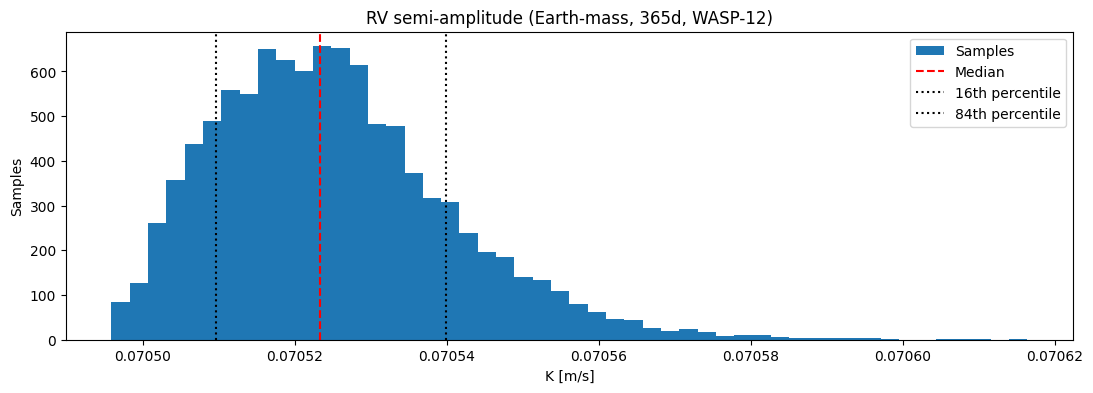

In [29]:
from astropy.constants import M_earth

P = 365 * u.day # Orbital period
P = P.to(u.s)

m = 1.0 * M_earth # Planet's mass

Mstar = 1.43 * u.M_sun # Star's mass

K = ((2*np.pi*G)/P)**(1/3) * (m / (Mstar**(2/3)))*1/((1-e**2)**(1/2))

K = K.to(u.m/u.s)


K_median = np.median(K.value) # Median
K_p16 = np.percentile(K.value, 16) # 16th percentile
K_p84 = np.percentile(K.value, 84) # 84th percentile

print(f"K = {median:.4f} (+{p84-median:.6f}/-{median-p16:.6f}) m/s")

plt.hist(K.value, bins=50, label="Samples")

plt.axvline(K_median, linestyle="--", color='red', label="Median")
plt.axvline(K_p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(K_p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel("K [m/s]")
plt.ylabel("Samples")
plt.title("RV semi-amplitude (Earth-mass, 365d, WASP-12)")

plt.legend()
plt.show()

---

<center>&copy;2026 Hannu Parviainen</center>